In [1]:
import pandas as pd
import numpy as np
import openpyxl
import pandas as pd
import re

def soft_key(x):
    if pd.isna(x):
        return x
    x = x.strip()
    x = re.sub(r'\s+', '', x)     # collapse all whitespace
    x = x.replace('-', '')        # remove hyphens only for comparison
    return x.upper()              # standard case for matching

In [2]:
example = pd.read_csv('example.txt', sep='\t')
example.head()

,SAMPLE_DATE,DUP_CODE,SYS_LOC_CODE,GRADIENT,CHEMICAL_NAME,REPLICATE_CODE,REPORT_RESULT_UNIT,REPORT_RESULT_TEXT,COMPARISON_LEVEL,LAB_QUALIFIERS
0,2/4/2026,NaN,MW-05DR,NaN,Antimony,NaN,ug/L,-1.0,NaN,NaN
1,2/4/2026,NaN,MW-05DR,NaN,Arsenic,NaN,ug/L,4.5,NaN,NaN
2,2/4/2026,NaN,MW-05DR,NaN,Barium,NaN,ug/L,170.0,NaN,NaN
3,2/4/2026,NaN,MW-05DR,NaN,Chromium,NaN,ug/L,-1.0,NaN,NaN
4,2/4/2026,NaN,MW-05DR,NaN,Copper,NaN,ug/L,-1.0,NaN,NaN


In [13]:
data_path = r"\\EMPLOYEES.ROOT.local\ENV\ECC\AnnArbor\PROJECTS\DANA\Marion, IN\2023\data eval\Q_Chemstat_2012-2023.xlsx"
clean_output_path = r"\\EMPLOYEES.ROOT.local\ENV\ECC\AnnArbor\PROJECTS\DANA\Marion, IN\2023\data eval\Q_Chemstat_2012-2023_cleaned.txt"

df = pd.read_excel(data_path)  # Replace with your actual dataframe loading method
df.head()

,Date Collected,DUP Code,SAMPLE ID,Gradient,Analyte,Replicate Code,Units,CONCENTRATION,Comparison,Comment
0,2012-04-24,NaN,MW-01,NaN,"1,1,1-Trichloroethane",NaN,UG/L,<0.65,NaN,NaN
1,2013-01-29,NaN,MW-01,NaN,"1,1,1-Trichloroethane",NaN,ug/L,<5,NaN,U
2,2013-06-06,NaN,MW-01,NaN,"1,1,1-Trichloroethane",NaN,ug/L,<5,NaN,U
3,2013-10-01,NaN,MW-01,NaN,"1,1,1-Trichloroethane",NaN,ug/L,<1,NaN,U
4,2013-10-28,NaN,MW-01,NaN,"1,1,1-Trichloroethane",NaN,ug/L,<1,NaN,U


<Axes: >

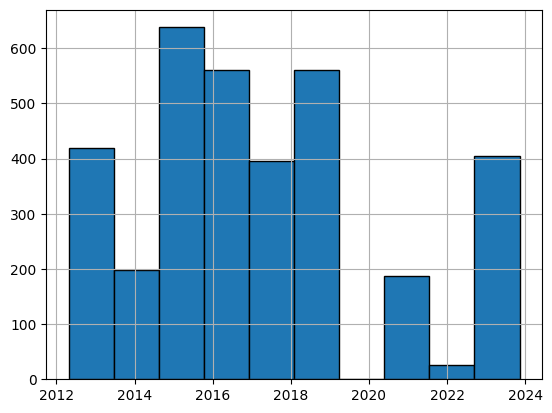

In [21]:
df['Date Collected'].hist(edgecolor='black' )

In [ ]:
df.rename(columns={"CONCENTRATION": "REPORT_RESULT_TEXT", "Date Collected": "DATE", "DUP Code": "DUP_CODE", "Gradient": "GRADIENT", 
                   "Replicate Code": "REPLICATE_CODE", "Units": "REPORT_RESULT_UNIT", "Comparison": "COMPARISON_LEVEL", 
                   "Lab Qualifiers": "LAB_QUALIFIERS", "SAMPLE ID": "SYS_LOC_CODE", "Analyte": "CHEMICAL_NAME", "Comment": "LAB_QUALIFIERS"}, inplace=True)  # Rename column if necessary

# Reorder columns to match template
df = df[["DATE", "DUP_CODE", "SYS_LOC_CODE", "GRADIENT", "CHEMICAL_NAME", "REPLICATE_CODE", "REPORT_RESULT_UNIT", "REPORT_RESULT_TEXT", "COMPARISON_LEVEL", "LAB_QUALIFIERS"]]

In [ ]:
# Clean REPORT_RESULT_TEXT by removing whitespace and replacing '<' with '-'
df2 = df.copy()
df2["REPORT_RESULT_TEXT"] = (
    df["REPORT_RESULT_TEXT"]
      .astype("string")                      # keeps NaN as <NA>
      .str.replace(r"\s+", "", regex=True)   # remove all whitespace
      .str.replace("<", "-", regex=False)    # replace '<' with '-'
)
# Clean REPORT_RESULT_UNIT by stripping whitespace and converting to lower case
df2.REPORT_RESULT_UNIT = df2.REPORT_RESULT_UNIT.str.lower().str.strip()
assert df2.REPORT_RESULT_UNIT.nunique() == 1
# Check for duplicates in SYS_LOC_CODE after cleaning

# Upper case all letters in SYS_LOC_CODE for consistency before applying soft_key
df2['SYS_LOC_CODE'] = df2['SYS_LOC_CODE'].str.upper()

# check for duplicates in SYS_LOC_CODE before applying soft_key
df2['sys_loc_key'] = df2["SYS_LOC_CODE"].apply(soft_key)
assert df2.SYS_LOC_CODE.nunique() == df2.sys_loc_key.nunique(), "Soft keys are not unique! Check for duplicates."
df2.drop(columns=["sys_loc_key"], inplace=True)

# check for duplicates in CHEMICAL_NAME before applying soft_key
df2['chemical_name_key'] = df2["CHEMICAL_NAME"].apply(soft_key)
assert df2.CHEMICAL_NAME.nunique() == df2.chemical_name_key.nunique(), "Soft keys are not unique! Check for duplicates."

In [ ]:
df2.to_csv(clean_output_path, index=False, sep='\t')

In [ ]:
# Threshold Report
# Starting point
threshold_report = df2.copy()

# Create boolean flag for non‑detects (REPORT_RESULT_TEXT beginning with "-")
threshold_report["is_nd"] = threshold_report["REPORT_RESULT_TEXT"].astype(str).str.startswith("-")

# Group by SYS_LOC_CODE and CHEMICAL_NAME
summary = (
    threshold_report
        .groupby(["SYS_LOC_CODE", "CHEMICAL_NAME"])
        .agg(
            total_results = ("is_nd", "count"),
            nd_count = ("is_nd", "sum")
        )
        .assign(
            pct_non_detect = lambda d: 100 * d["nd_count"] / d["total_results"]
        )
        .reset_index()
)

summary.to_excel(r"\\EMPLOYEES.ROOT.local\ENV\ECC\AnnArbor\PROJECTS\DANA\Marion, IN\2023\data eval\Q_Chemstat_2012-2023_summary.xlsx", index=False, sheet_name="Summary")

In [6]:
def _add_zero_concentration_records(df):
    # Identify unique combinations of well + parameter
    unique_pairs = df[['SYS_LOC_CODE', 'CHEMICAL_NAME']].drop_duplicates()

    # Create a new dataframe for the 1/1/2027 zero‑concentration records
    new_rows = unique_pairs.copy()
    new_rows['SAMPLE_DATE'] = '1/1/2027'
    new_rows['DUP_CODE'] = ""
    new_rows['GRADIENT'] = ""
    new_rows['REPLICATE_CODE'] = ""
    new_rows['REPORT_RESULT_UNIT'] = "ug/L"
    new_rows['REPORT_RESULT_TEXT'] = 0
    new_rows['COMPARISON_LEVEL'] = ""
    new_rows['LAB_QUALIFIERS'] = ""

    # Reorder columns to match original dataframe
    new_rows = new_rows[df.columns]

    # Append new rows to the original dataframe
    df_out = pd.concat([df, new_rows], ignore_index=True)

    # Optional: sort result
    return df_out.sort_values(['SYS_LOC_CODE', 'CHEMICAL_NAME', 'SAMPLE_DATE'])